# **Description**  
 The dataset is sourced from the Water Potability dataset, containing the physical and chemical measurements of 3,276 water bodies. The primary goal is to predict whether the water is safe for human consumption (Potable) or not, based on these water quality metrics.

# **1.Important Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **2.Data Collection**

In [3]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/water_potability.csv'

water_data = pd.read_csv(path)
water_data.head(15)

Mounted at /content/drive


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


# **3.EDA (Exploratory Data Analysis)**

In [4]:
print("""
Key Insights:
1. Dataset had missing values which were filled using median.
2. Data is slightly imbalanced (more unsafe water samples).
3. Some features like Solids, Conductivity show wide variation.
4. Correlation between features is generally low.
5. Outliers exist in multiple columns.
6. Certain features show different distributions for safe vs unsafe water.
""")


Key Insights:
1. Dataset had missing values which were filled using median.
2. Data is slightly imbalanced (more unsafe water samples).
3. Some features like Solids, Conductivity show wide variation.
4. Correlation between features is generally low.
5. Outliers exist in multiple columns.
6. Certain features show different distributions for safe vs unsafe water.



In [5]:
print(water_data.shape)

(3276, 10)


In [6]:
water_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
print(water_data.describe())

                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085    41.416840   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.093092   176.850538  15666.690297     6.127421   307.699498   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       8.062066   216.667456  27332.762127     8.114887   359.950170   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3114.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3.966786     0.390110  
std       80.824064        3.308162        16.175008     0.780382     0.487849  


In [8]:
water_data.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [9]:
from sklearn.impute import SimpleImputer

features_potability = water_data.drop('Potability', axis=1)
fill_null = SimpleImputer(strategy='median')

features_imputed = fill_null.fit_transform(features_potability)
water_data[features_potability.columns] = features_imputed

print(water_data.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [10]:
water_data.head(15)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,7.036752,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


# **4.Visualization - Diagrams**

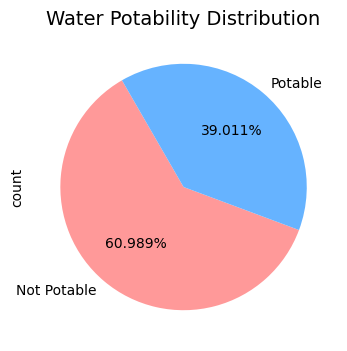

In [11]:
#pie chart
plt.figure(figsize=(6, 4))
water_data['Potability'].value_counts().plot(
    kind='pie',
    autopct='%1.3f%%',
    colors=['#ff9999', '#66b3ff'],
    labels=['Not Potable', 'Potable'],
    startangle=120
)
plt.title("Water Potability Distribution", fontsize=14)
plt.show()

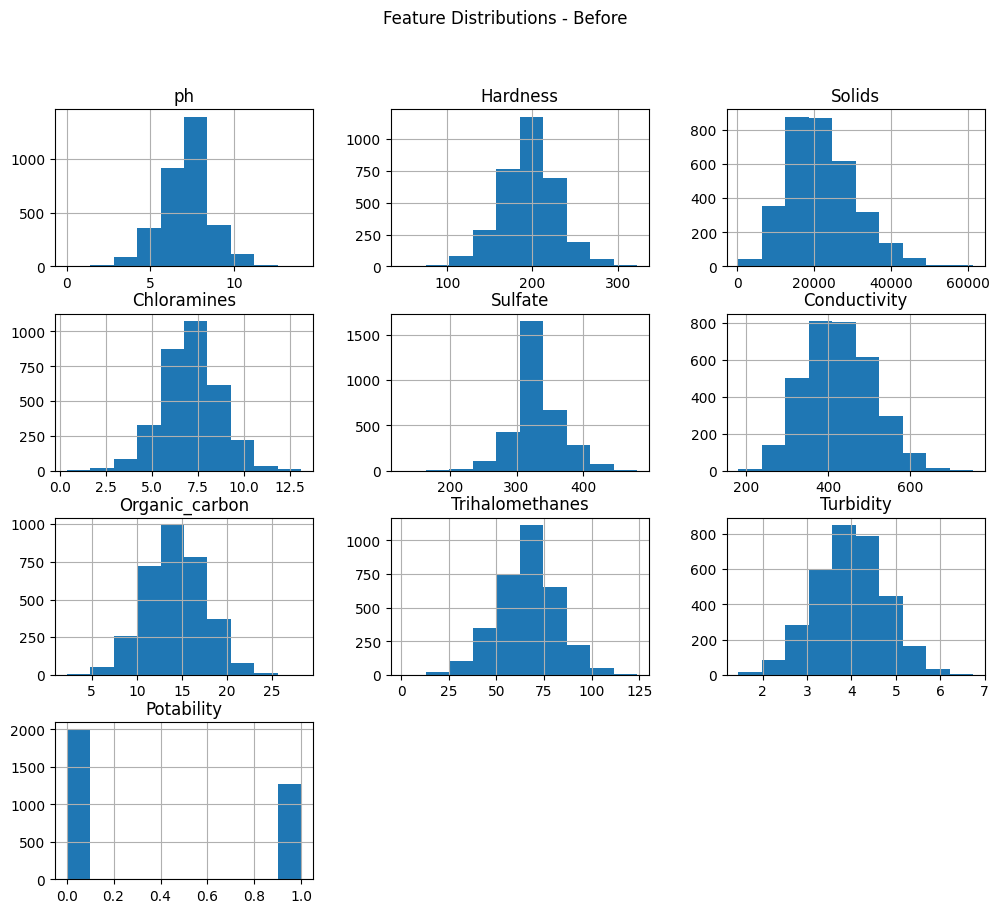

In [12]:
# Histogram plot
water_data.hist(figsize=(12,10))
plt.suptitle('Feature Distributions - Before')
plt.show()

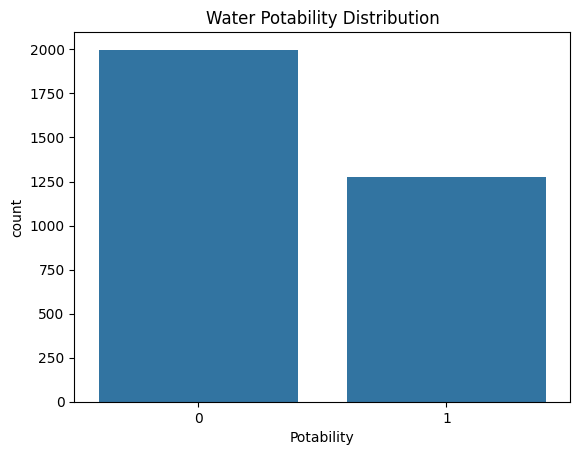

In [13]:
# Target distribution
plt.figure()
sns.countplot(x='Potability', data=water_data)
plt.title('Water Potability Distribution')
plt.show()

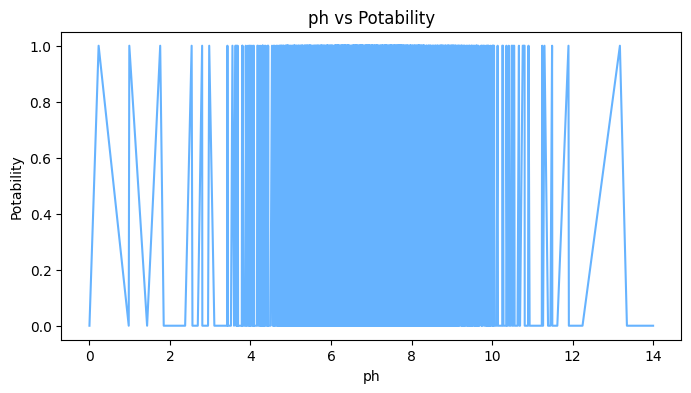

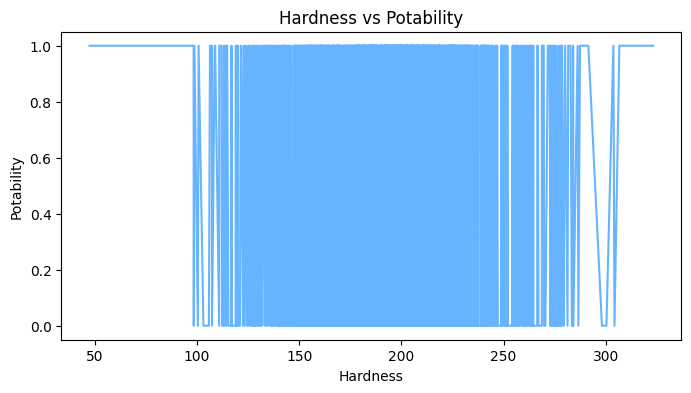

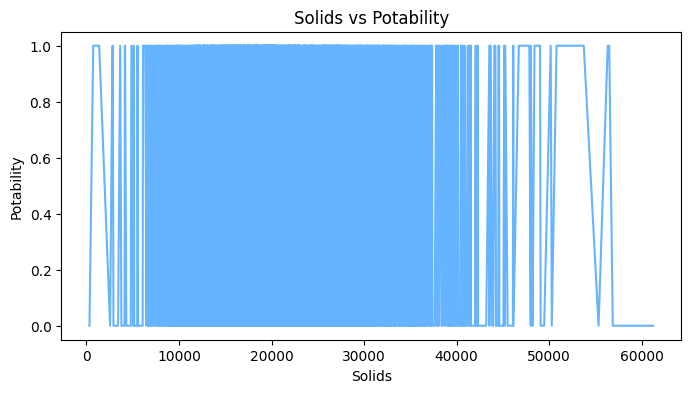

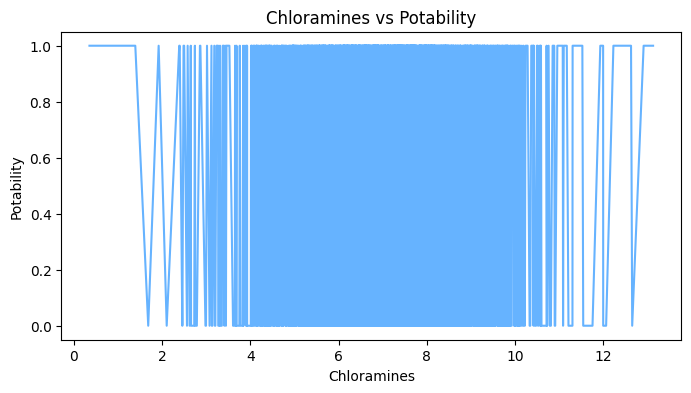

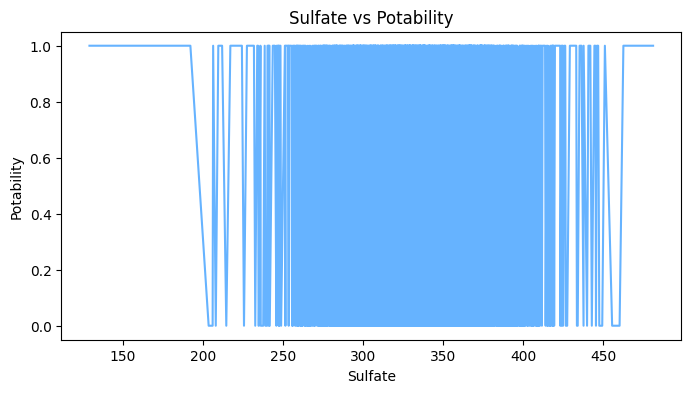

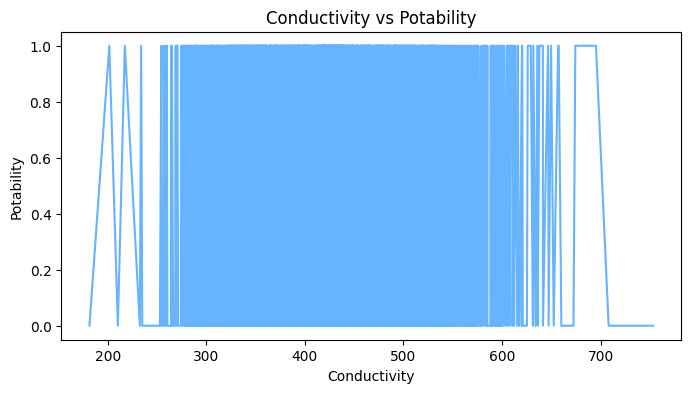

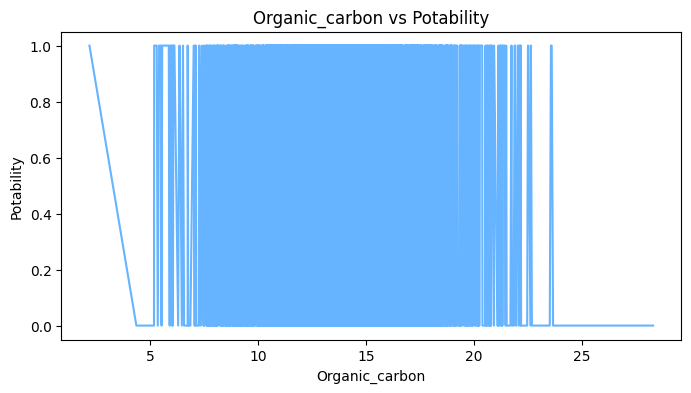

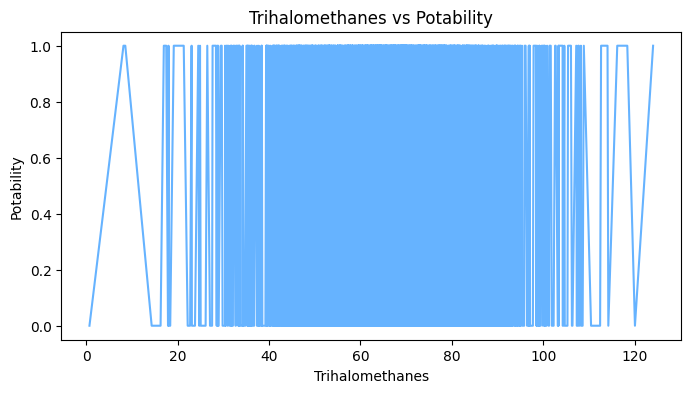

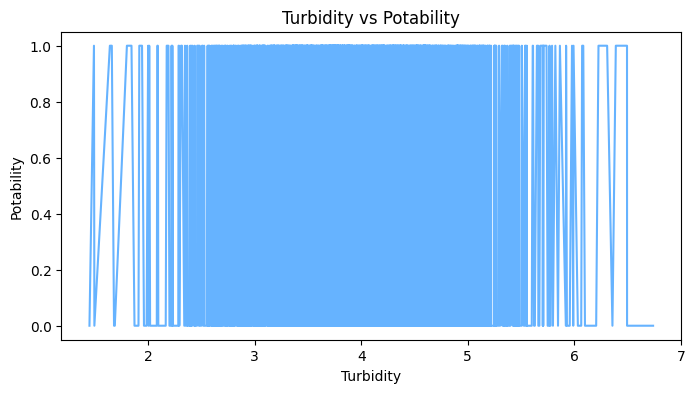

In [14]:
#line plot
for col in water_data.columns:
    if col != 'Potability':
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=water_data[col], y=water_data['Potability'], color='#66b3ff')

        plt.title(f'{col} vs Potability')
        plt.xlabel(col)
        plt.ylabel('Potability')
        plt.show()

In [15]:
#Correlation matrix Results Before Heatmap
correl_matrix = water_data.corr()
print(correl_matrix['Potability'].sort_values(ascending=False))

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.006887
Turbidity          0.001581
ph                -0.003014
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.020476
Organic_carbon    -0.030001
Name: Potability, dtype: float64


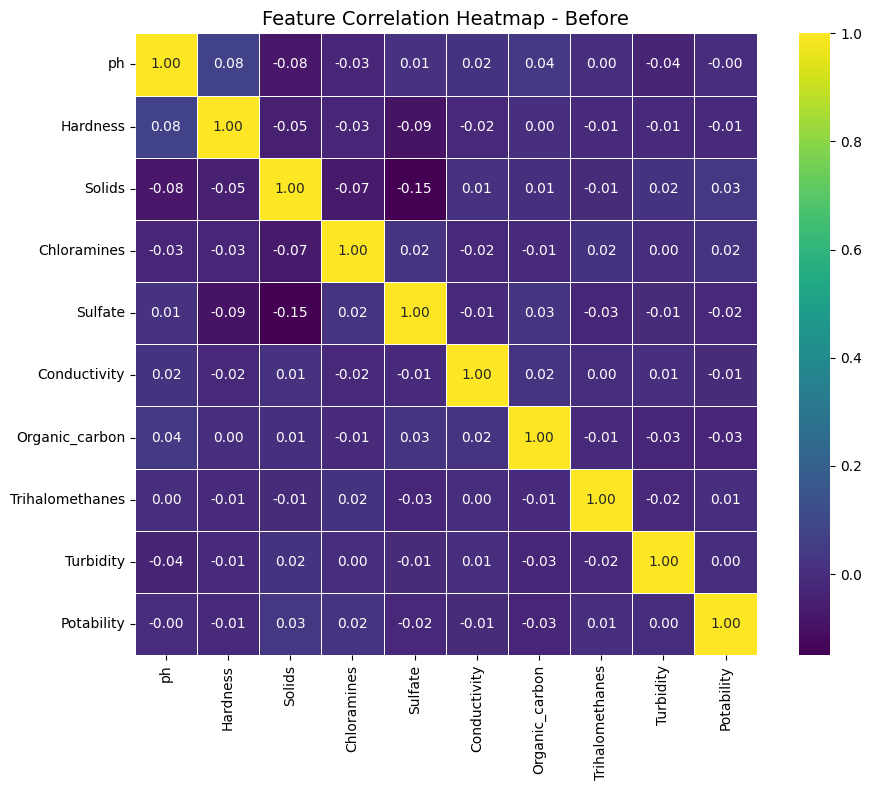

In [16]:
#heatmap before
plt.figure(figsize=(10, 8))
sns.heatmap(
    correl_matrix,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    linewidths=0.6,
    square=True
)
plt.title('Feature Correlation Heatmap - Before', fontsize=14)
plt.tight_layout()
plt.show()

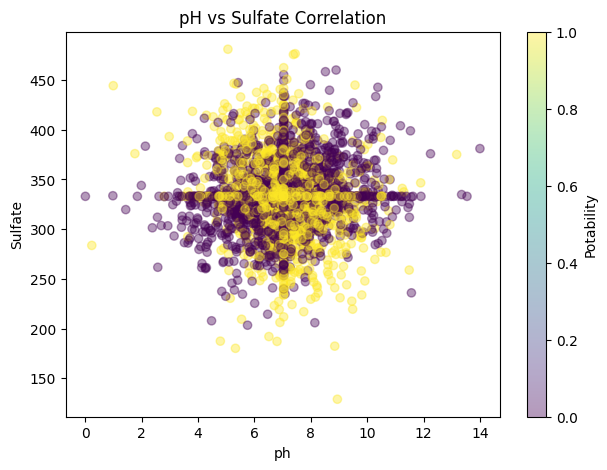

In [17]:
#Scatter for ph and sulfate
plt.figure(figsize=(7, 5))
plt.scatter(water_data['ph'], water_data['Sulfate'],
            c=water_data['Potability'], alpha=0.4, cmap='viridis')
plt.xlabel('ph')
plt.ylabel('Sulfate')
plt.title('pH vs Sulfate Correlation')
plt.colorbar(label='Potability')
plt.show()

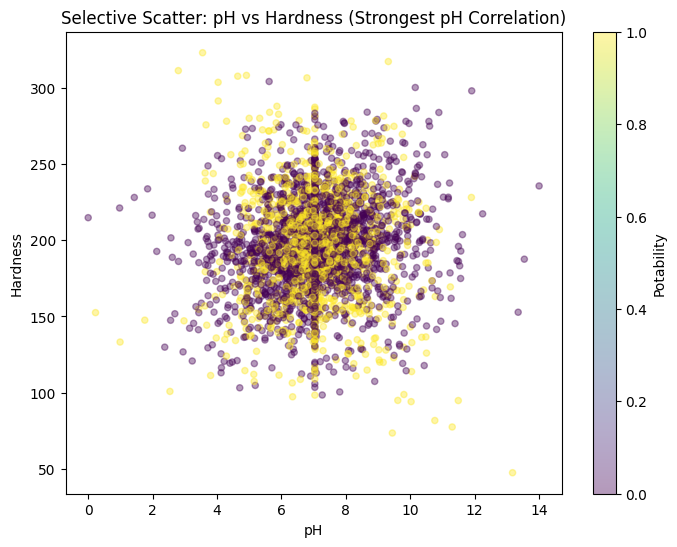

In [19]:
#scatter for second Strongest correlation
plt.figure(figsize=(8, 6))
plt.scatter(water_data['ph'], water_data['Hardness'],
            c=water_data['Potability'],
            alpha=0.4,
            s=20,
            cmap='viridis')

plt.xlabel('pH')
plt.ylabel('Hardness')
plt.title('Selective Scatter: pH vs Hardness (Strongest pH Correlation)')
plt.colorbar(label='Potability')
plt.show()

# **5.Data Preprocessing**

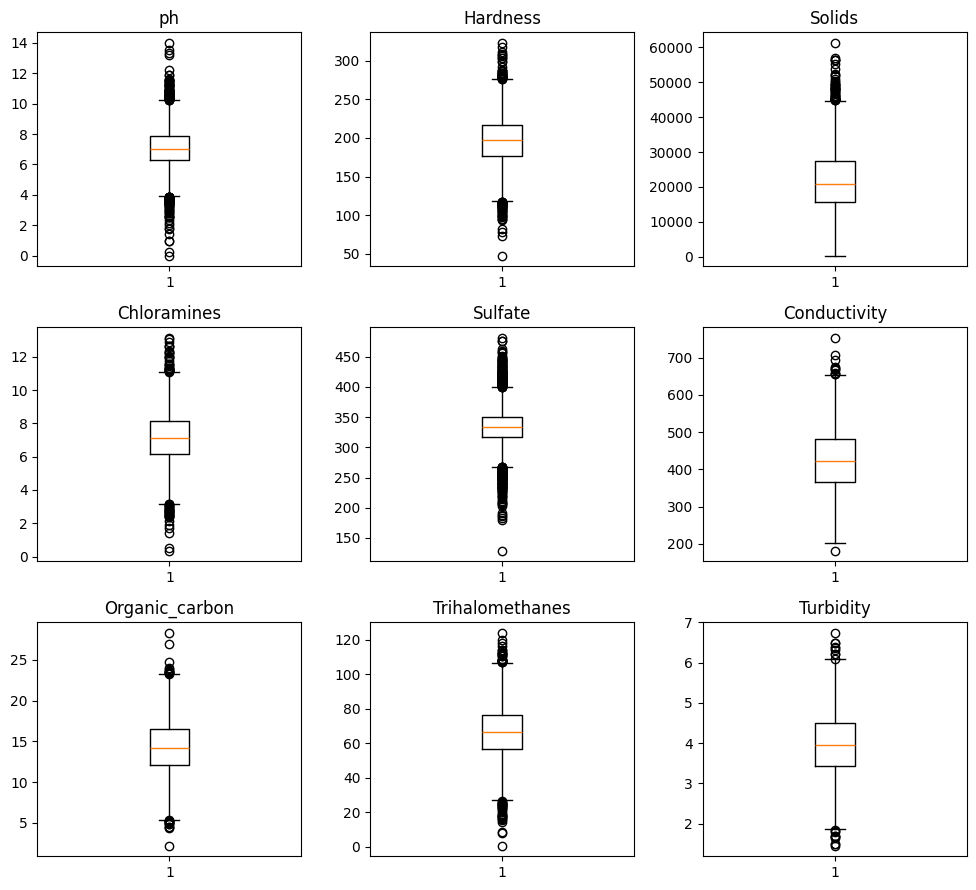

In [20]:
#box plot - before
cols = [col for col in water_data.columns if col != 'Potability']

plt.figure(figsize=(10, 3 * ((len(cols) + 2) // 3)))

for i, col in enumerate(cols):
    plt.subplot((len(cols) + 2) // 3, 3, i + 1)
    plt.boxplot(water_data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [21]:
for col in water_data.columns:
    if col != "Potability":
        Q1 = water_data[col].quantile(0.25)
        Q3 = water_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = water_data[(water_data[col] < lower_bound) | (water_data[col] > upper_bound)]

        print(f"{col}: {len(outliers)} outliers")

ph: 142 outliers
Hardness: 83 outliers
Solids: 47 outliers
Chloramines: 61 outliers
Sulfate: 264 outliers
Conductivity: 11 outliers
Organic_carbon: 25 outliers
Trihalomethanes: 54 outliers
Turbidity: 19 outliers


In [22]:
for col in water_data.columns:
    if col != "Potability":
        Q1 = water_data[col].quantile(0.25)
        Q3 = water_data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        water_data[col] = water_data[col].clip(lower, upper)


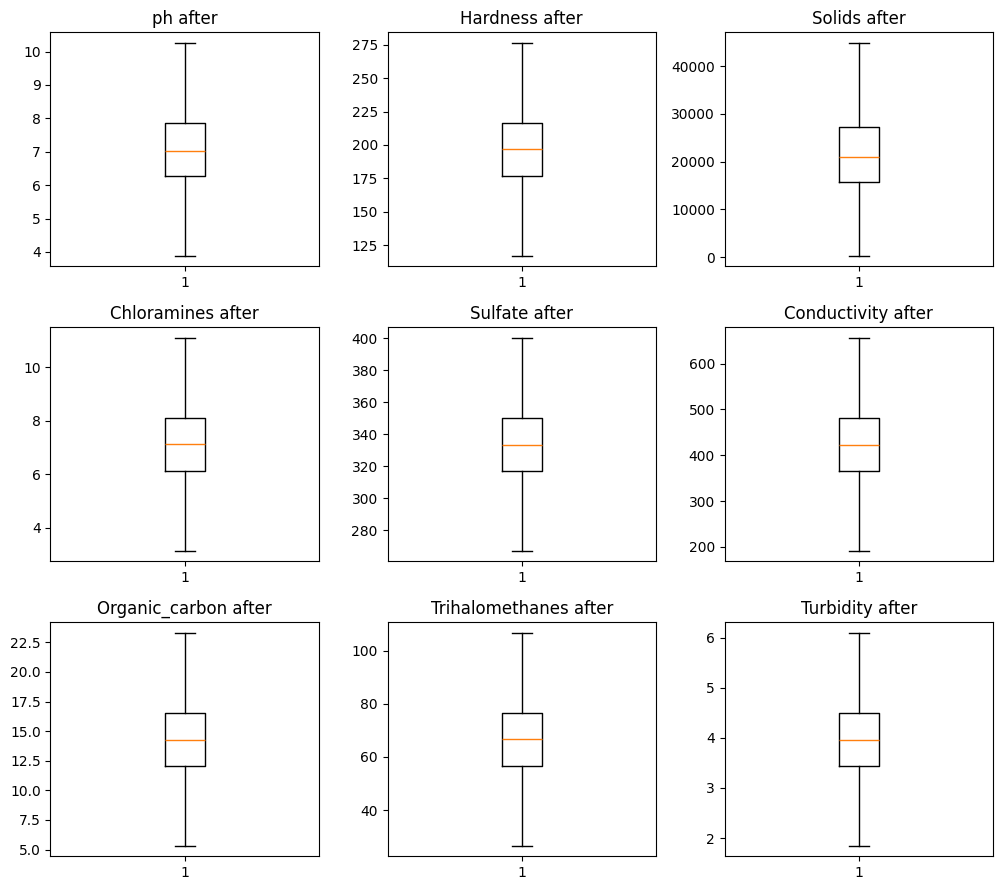

In [23]:
#Box Plot - After
cols = [col for col in water_data.columns if col != "Potability"]

plt.figure(figsize=(10, 3 * ((len(cols) + 2) // 3)))

for i, col in enumerate(cols):
    plt.subplot((len(cols) + 2) // 3, 3, i + 1)
    plt.boxplot(water_data[col])
    plt.title(col + " after")

plt.tight_layout()
plt.show()

In [24]:
#Splitting (Train - Test)
from sklearn.model_selection import train_test_split

X = water_data.drop('Potability', axis=1)
y = water_data['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


print(f"num of traning set : {len(X_train)}")
print(f"num of testing set: {len(X_test)}")

num of traning set : 2293
num of testing set: 983


In [25]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

X = water_data.drop("Potability", axis=1)
y = water_data["Potability"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_train
X_test = sc.transform(X_test)
X_test

array([[-0.03545885, -0.4066146 , -0.18240708, ...,  1.81050143,
         0.0342416 ,  1.19931708],
       [-0.32127638, -0.23868083,  1.24524793, ...,  0.13922728,
         0.08720073,  0.78015495],
       [ 0.55223847,  0.85583206,  0.13996887, ..., -0.2578289 ,
        -1.50294018, -1.89968933],
       ...,
       [ 0.14752593,  1.16473223,  1.10070106, ..., -0.61863979,
        -2.2266447 , -0.55162583],
       [ 0.11466326,  0.01260277,  0.88848842, ..., -0.02931531,
        -1.01633796,  1.04033321],
       [-0.31365822, -0.74720728,  1.46868258, ...,  0.4952336 ,
         0.09567607,  1.17964347]])

In [27]:
#Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

selector= SelectKBest(score_func=f_classif, k=5)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features_names = X.columns[selector.get_support()]

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")
print("Top features are:", list(selected_features_names))

Original features: 9
Selected features: 5
Top features are: ['Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Organic_carbon']


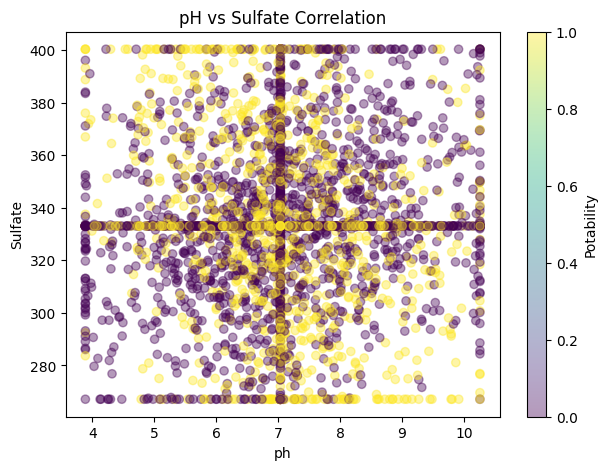

In [28]:
#Scatter for ph and sulfate
plt.figure(figsize=(7, 5))
plt.scatter(water_data['ph'], water_data['Sulfate'],
            c=water_data['Potability'], alpha=0.4, cmap='viridis')
plt.xlabel('ph')
plt.ylabel('Sulfate')
plt.title('pH vs Sulfate Correlation')
plt.colorbar(label='Potability')
plt.show()

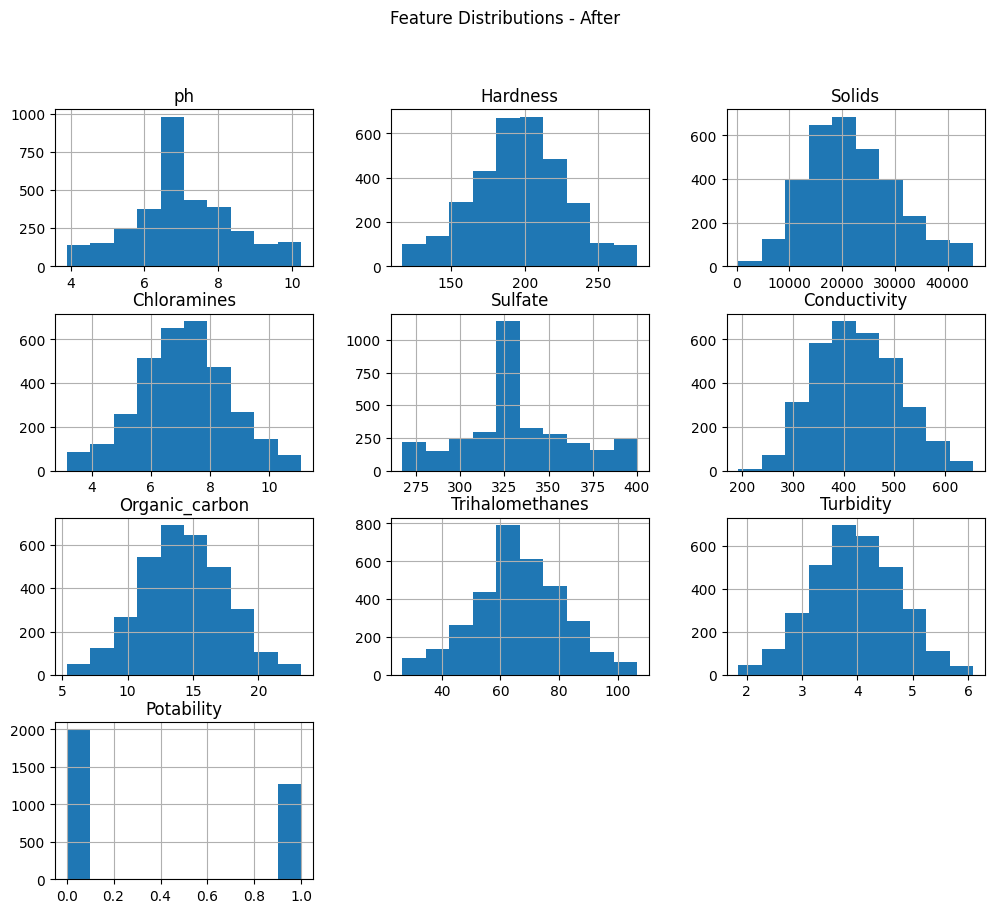

In [29]:
#Feature Distributions - After
water_data.hist(figsize=(12,10))
plt.suptitle('Feature Distributions - After')
plt.show()

# **6.**Model** Training** **& Evaluation**

## **a.Random Forest ALGO**

In [30]:
#Random Forest ALGO
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_optimized = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=2,
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_optimized.fit(X_train, y_train)
y_pred_rf = rf_optimized.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)


print(f"Optimized Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Optimized Accuracy Score: 67.96%

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       617
           1       0.62      0.37      0.46       366

    accuracy                           0.68       983
   macro avg       0.66      0.62      0.62       983
weighted avg       0.67      0.68      0.66       983



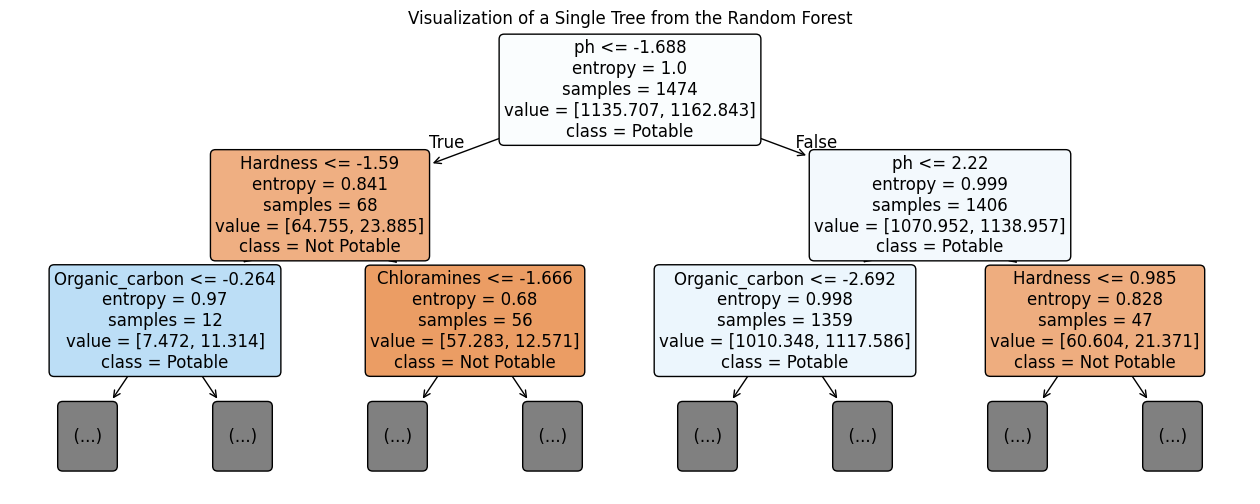

In [31]:
#Visualization RF Model
from sklearn.tree import plot_tree

chosen_tree = rf_optimized.estimators_[0]

plt.figure(figsize=(16, 6))
plot_tree(chosen_tree,
          feature_names=list(X.columns),
          class_names=['Not Potable', 'Potable'],
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=2)

plt.title("Visualization of a Single Tree from the Random Forest")
plt.show()

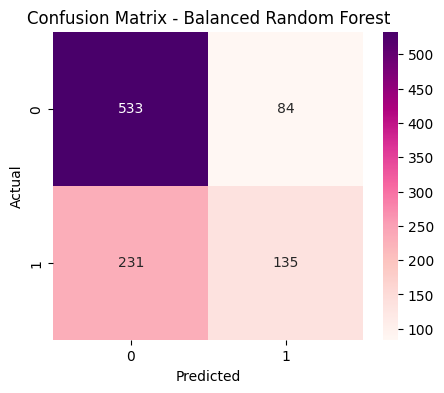

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')
plt.title("Confusion Matrix - Balanced Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **b.Support Vector Machine ALGO**

In [34]:
#Support Vector Machine ALGO
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_optimized = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)
svm_optimized.fit(X_train, y_train)
y_pred_svm = svm_optimized.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"Optimized SVM Accuracy Score: {accuracy_svm * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Optimized SVM Accuracy Score: 66.43%

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       617
           1       0.55      0.55      0.55       366

    accuracy                           0.66       983
   macro avg       0.64      0.64      0.64       983
weighted avg       0.66      0.66      0.66       983



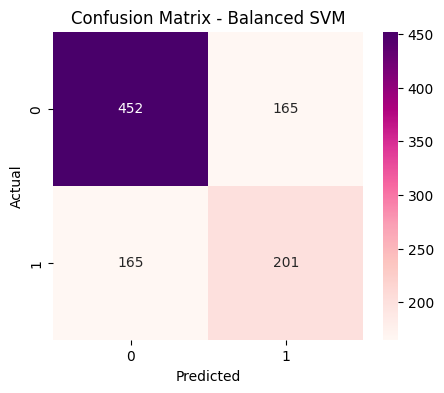

In [35]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='RdPu')

plt.title("Confusion Matrix - Balanced SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

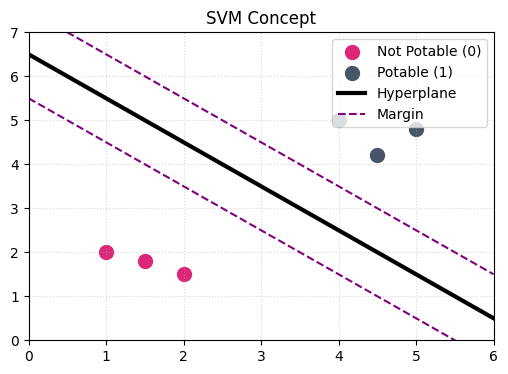

## **c.KNN ALGO**

In [ ]:
#KNN ALGO
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=11, weights='distance')
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {accuracy_knn * 100:.2f}%")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 65.51%
              precision    recall  f1-score   support

           0       0.68      0.84      0.75       617
           1       0.56      0.34      0.42       366

    accuracy                           0.66       983
   macro avg       0.62      0.59      0.59       983
weighted avg       0.64      0.66      0.63       983



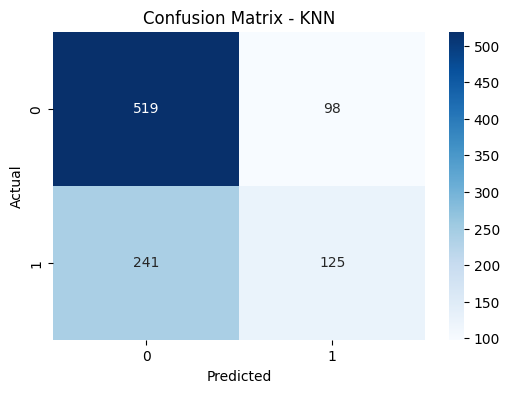

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced KNN")
plt.show()

## **d.Decision Tree Algo**

In [37]:
#Decision Tree Algo
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)


print(f"Decision Tree Accuracy: {dt_acc * 100:.2f}%")
print("-" * 30)
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 64.60%
------------------------------

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.90      0.76       617
           1       0.56      0.22      0.31       366

    accuracy                           0.65       983
   macro avg       0.61      0.56      0.54       983
weighted avg       0.62      0.65      0.60       983



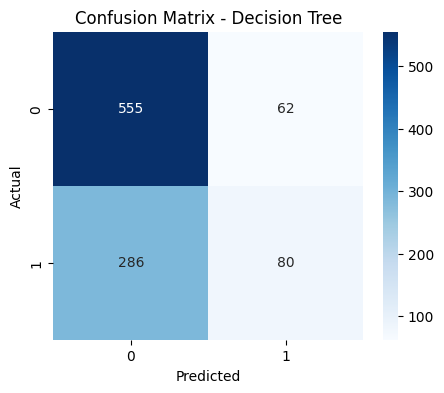

In [39]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **e.LogisticRegression ALGO**

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model = LogisticRegression(max_iter=1000 , class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Logistic Accuracy Score: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Accuracy Score: 52.09%

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58       617
           1       0.39      0.51      0.44       366

    accuracy                           0.52       983
   macro avg       0.52      0.52      0.51       983
weighted avg       0.55      0.52      0.53       983



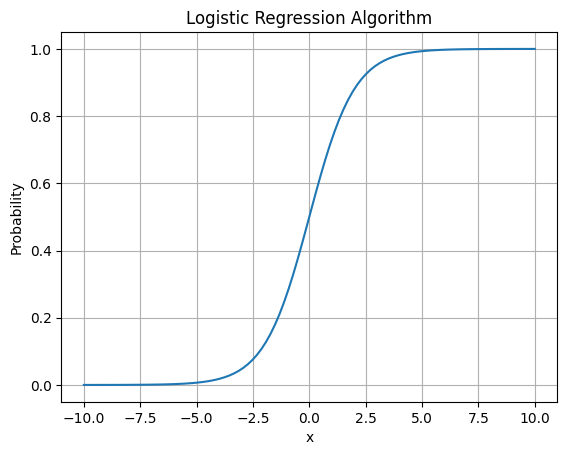

In [41]:
#Sigmoid Function (Logisitic Function)
x = np.linspace(-10, 10, 100)

y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.title("Logistic Regression Algorithm")
plt.xlabel("x")
plt.ylabel("Probability")
plt.grid(True)
plt.show()


Confusion Matrix:
[[325 292]
 [179 187]]


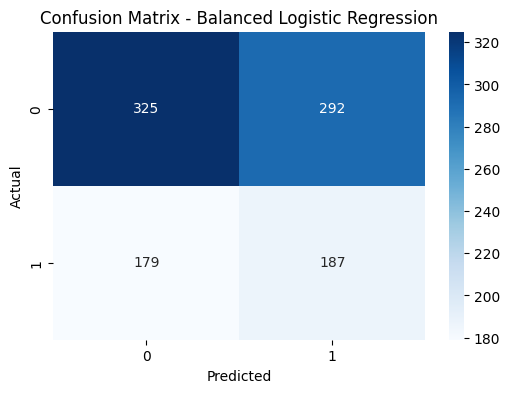

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

## **f.XGBoost ALGO**

In [43]:
#XGBoost ALGO
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:52:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 65.01%

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.78      0.74       617
           1       0.54      0.43      0.48       366

    accuracy                           0.65       983
   macro avg       0.62      0.60      0.61       983
weighted avg       0.64      0.65      0.64       983



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:03:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 1000x800 with 0 Axes>

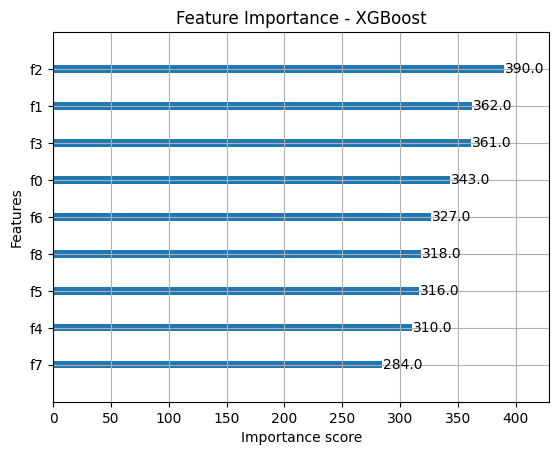

In [ ]:
#Features Affect - Importance
xgb_model.fit(X_train, y_train)
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(xgb_model, importance_type='weight')
plt.title("Feature Importance - XGBoost")
plt.show()